# 7.1 Introduction and Concepts

**Part:** 7 — Spatial Interpolation (Chapter 7.1 of 8)

**Dataset:** `CA_pm25_2025.csv` (163 California air-quality monitors, illustrative only in this chapter)

**Focus:** the interpolation problem; deterministic vs. geostatistical methods; why uncertainty matters

**Library:** `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Field, Lattice, or Points?](#3.-Field,-Lattice,-or-Points?)
4.. [Smoothness and Stationarity](#4.-Smoothness-and-Stationarity)
5.. [Exact vs. Smoothing Interpolators](#5.-Exact-vs.-Smoothing-Interpolators)
6.. [Why Deterministic Methods Give No Uncertainty](#6.-Why-Deterministic-Methods-Give-No-Uncertainty)
7.. [A First Look at the Data](#7.-A-First-Look-at-the-Data)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Every method in this Part answers the same question in a different way: **given measurements at a finite set
of locations, what value would we expect somewhere we did not measure?** Part 0 (§0.3) introduced three ways to
represent spatial data — a continuous **geostatistical field** $Z(\mathbf{s})$, a **lattice** $\{Z_i\}$ tied to
fixed areal units, and a **point pattern** governed by an intensity $\lambda(\mathbf{s})$. This Part works
entirely in the first regime: air pollution, soil chemistry, or disease rates are treated as if they were
realizations of a continuous underlying field, sampled at a finite, often irregular, set of monitor or survey
locations.

| Step | What we do |
|------|------------|
| Frame the problem | Field vs. lattice vs. point pattern; why interpolation only makes sense for the first |
| Two families | Deterministic (IDW, TIN, splines) vs. geostatistical (kriging) — and what geostatistics adds |
| Exact vs. smoothing | Does the surface pass through every observation, or is it allowed to disagree with noisy data |
| Uncertainty | Why only a model of spatial correlation, not distance-weighting alone, can say how *confident* a prediction is |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Field, Lattice, or Points?

Part 4 (cluster detection) and Part 6 (geographically weighted models) both worked with **lattice** data —
county-level rates, tied to fixed polygons, where the unit of analysis (`diabetes_northeast.shp`) is given in
advance and does not change. This Part's air-quality monitors are different: a PM2.5 reading exists at a monitor
because a sensor happens to sit there, not because the monitor *defines* a spatial unit. Conceptually, PM2.5
concentration exists **everywhere** in California — the 163 monitors are a sparse, irregular sample of a field
$Z(\mathbf{s})$ that is defined at every point $\mathbf{s}$ in the domain, whether or not it was ever measured
there. Interpolation is the attempt to recover that field, or at least a plausible smoothed version of it, from
the sample.

This distinction matters for method choice: lattice data (Part 6's counties) call for models that respect a
fixed set of polygons; point-pattern data (Part 1's case locations) call for models of *event density*; only
genuinely field-like data — continuous, defined everywhere, sampled at a finite set of locations — calls for the
methods in this Part.

***
## 4. Smoothness and Stationarity

Every interpolator in this Part makes an implicit assumption: **nearby locations tend to have similar values**.
Without that assumption there is nothing to interpolate — a value at an unsampled location would be exactly as
likely to resemble its nearest neighbour as a monitor on the other side of the state. The geostatistical
methods in Chapter 7.4 go one step further and assume (second-order) **stationarity**: the *strength* of that
similarity — how much values decorrelate with distance — is the same everywhere in the domain, so a single
variogram, estimated once from all the data, can describe local correlation structure anywhere in it. This is
the same stationarity assumption Part 3 needed for global regression and Part 6 challenged with locally varying
coefficients — here it appears again, applied not to a regression relationship but to the covariance structure
of the field itself.

***
## 5. Exact vs. Smoothing Interpolators

An **exact** interpolator reproduces every observed value precisely: predicting back at a monitor's own
location returns exactly what that monitor measured. Nearest-neighbour, TIN, IDW, and ordinary kriging (with
zero nugget) are all exact in this sense. A **smoothing** interpolator is allowed to disagree with the
observations — useful when the data themselves are noisy (measurement error, a monitor with an unusual local
microenvironment) and passing an exact surface through every point would just be interpolating the noise.
`RBF`/`Spline`'s `smoothing` parameter and ordinary kriging's **nugget** effect (Chapter 7.4) both relax
exactness deliberately, trading a perfect fit at the data points for a more plausible surface in between them.

***
## 6. Why Deterministic Methods Give No Uncertainty

`NearestNeighbor`, `TIN`, `IDW`, and `RBF` (Chapter 7.3) all produce a single number at every prediction
location — a best guess, with no accompanying measure of how much to trust it. This is not an implementation
gap; it follows directly from what these methods *are*: fixed, geometry-based weighting rules. IDW's weight
$w_i \propto 1/d_i^p$ depends only on distance, never on how the observations happen to be arranged relative to
each other or how noisy they are. Two networks with identical monitor locations but wildly different underlying
spatial correlation would get **exactly the same** IDW prediction, because IDW never looks at the data's actual
correlation structure to begin with.

Kriging (Chapter 7.4) is different because it is built from an explicit statistical model of the field:
$$
\gamma(h) = \tfrac{1}{2}\,\mathrm{Var}\!\left[Z(\mathbf{s}+h) - Z(\mathbf{s})\right]
$$
Once that model (the variogram) is estimated, the kriging system exposes a **prediction variance** at every
location — smaller where observations are dense and mutually informative, larger in gaps in the network —
**computed from the sampling configuration and the variogram alone, independent of the observed values
themselves.** That variance is the actual payoff of the geostatistical approach, and it is precisely what a
purely geometric weighting scheme like IDW cannot offer.

***
## 7. A First Look at the Data

The dataset for most of this Part: daily PM2.5 readings from 163 EPA monitors across California in 2025 —
enough of a preview here to motivate the concepts above; Chapter 7.2 does the full preparation.

rows: 59,566   monitors: 163   date range: 01/01/2025 to 12/31/2025
observations per monitor: min=47, median=358, max=851


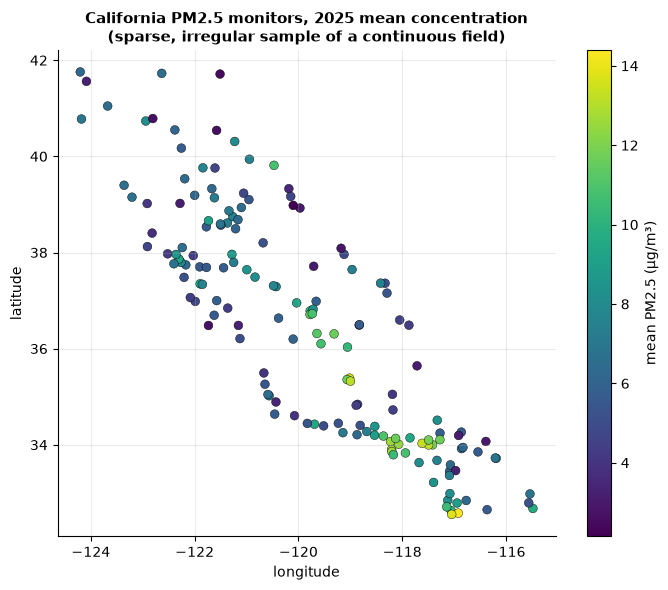

In [2]:
pm25_raw = pd.read_csv(DATA / "CA_pm25_2025.csv")
print(f"rows: {len(pm25_raw):,}   monitors: {pm25_raw['Site ID'].nunique()}   "
      f"date range: {pm25_raw['Date'].min()} to {pm25_raw['Date'].max()}")

site_counts = pm25_raw.groupby("Site ID").size()
print(f"observations per monitor: min={site_counts.min()}, median={site_counts.median():.0f}, max={site_counts.max()}")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pm25_raw.groupby("Site ID")["Long"].first(), pm25_raw.groupby("Site ID")["Lat"].first(),
                c=pm25_raw.groupby("Site ID")["Daily_PM2.5_ug_m3"].mean(), cmap="viridis", s=40, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, ax=ax, label="mean PM2.5 (µg/m³)")
ax.set_title("California PM2.5 monitors, 2025 mean concentration\n(sparse, irregular sample of a continuous field)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout()
plt.savefig("monitor_overview.png", dpi=100, bbox_inches="tight")
plt.show()

Even this quick look shows the two ingredients every method in this Part needs to reckon with: monitors are
**irregularly spaced** (dense around the Bay Area and Los Angeles basin, sparse in the northern mountains and
deserts) and mean concentrations show clear **spatial structure** — nearby monitors tend to report similar
values, exactly the assumption Section 4 named. Chapter 7.2 turns this raw daily-observation table into the
clean, projected, site-level dataset every later chapter builds on.

***
## 8. Summary and Conclusions

This chapter framed the interpolation problem this whole Part solves, before writing any interpolator.

### What we did

1. Distinguished field data (this Part) from lattice data (Parts 4, 6) and point-pattern data (Part 1) — only
   the first calls for spatial interpolation in the sense used here.
2. Explained the stationarity assumption every method in this Part relies on, in some form.
3. Distinguished exact interpolators (pass through every observation) from smoothing ones (allowed to disagree
   with noisy data).
4. **Explained precisely why deterministic methods (IDW, TIN, splines) cannot produce a prediction variance**:
   their weights depend only on geometry, never on an explicit model of the field's correlation structure —
   motivating kriging (Chapter 7.4) as the method that can.
5. Previewed the PM2.5 monitor network: irregular, spatially structured, and the dataset most of this Part uses.

### Practical takeaways

- Before reaching for any interpolator, confirm the data really are field-like (defined everywhere, sampled at
  a finite set of locations) rather than lattice or point-pattern data that belong to earlier Parts' methods.
- A deterministic method's prediction is only ever a point estimate; if a decision depends on how confident that
  estimate is, kriging (or an ensemble/resampling approach) is required, not IDW or TIN.

### Next steps

**Chapter 7.2 (Data and Preparation)** builds the actual site-level, projected dataset — aggregating repeated
daily readings to site means, filtering to well-sampled sites, and projecting to a metric CRS, all of which
every later chapter depends on.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | The classical field/lattice/point-pattern taxonomy used throughout this chapter |
| Isaaks, E. H. & Srivastava, R. M. (1989). *An Introduction to Applied Geostatistics*. Oxford University Press. | An accessible first treatment of stationarity and the exact-vs-smoothing distinction |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate` | The whole module this Part documents |
| Part 0, §0.3 | The field/lattice/point-pattern taxonomy this chapter builds on |
| Chapter 7.2 | Builds the actual dataset this chapter previewed |
| Chapter 7.4 | Delivers on Section 6's promise: kriging's prediction variance |